# Project: Investigate a Dataset - TMDb Movie Data

## Table of Contents
<ul>
<li><a href="#intro">Introduction</a></li>
<li><a href="#wrangling">Data Wrangling</a></li>
<li><a href="#eda">Exploratory Data Analysis</a></li>
<li><a href="#conclusions">Conclusions</a></li>
</ul>

<a id='intro'></a>
## Introduction

### Dataset Description

This dataset contains information about approximately 10,000 movies collected from The Movie Database (TMDb). Each row represents a single movie and includes 21 columns covering:

- **Identifiers:** `id`, `imdb_id`
- **Financials:** `budget`, `revenue`, `budget_adj`, `revenue_adj` (the `_adj` columns are adjusted for inflation to 2010 dollars)
- **Ratings & Popularity:** `popularity`, `vote_count`, `vote_average`
- **Movie Details:** `original_title`, `cast`, `director`, `homepage`, `tagline`, `keywords`, `overview`
- **Categorical/Temporal:** `genres`, `production_companies`, `runtime`, `release_date`, `release_year`

### Questions for Analysis

1. **What properties are associated with high-revenue movies?**  
   Dependent variable: `revenue_adj`. Independent variables: `budget_adj`, `popularity`, `vote_average`.

2. **How has the movie industry changed over the years?**  
   Examining trends in number of releases, average budget, and average runtime across `release_year`.

3. **Which genres are the most profitable and most popular?**  
   Comparing genres by median revenue and median popularity.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style('whitegrid')

<a id='wrangling'></a>
## Data Wrangling

### General Properties

In [2]:
# Load the dataset
df = pd.read_csv('Database_TMDb_movie_data/tmdb-movies.csv')
df.head()

,id,imdb_id,popularity,budget,revenue,original_title,cast,homepage,director,tagline,...,overview,runtime,genres,production_companies,release_date,vote_count,vote_average,release_year,budget_adj,revenue_adj
0,135397,tt0369610,32.985763,150000000,1513528810,Jurassic World,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,http://www.jurassicworld.com/,Colin Trevorrow,The park is open.,...,Twenty-two years after the events of Jurassic ...,124,Action|Adventure|Science Fiction|Thriller,Universal Studios|Amblin Entertainment|Legenda...,6/9/15,5562,6.5,2015,1.379999e+08,1.392446e+09
1,76341,tt1392190,28.419936,150000000,378436354,Mad Max: Fury Road,Tom Hardy|Charlize Theron|Hugh Keays-Byrne|Nic...,http://www.madmaxmovie.com/,George Miller,What a Lovely Day.,...,An apocalyptic story set in the furthest reach...,120,Action|Adventure|Science Fiction|Thriller,Village Roadshow Pictures|Kennedy Miller Produ...,5/13/15,6185,7.1,2015,1.379999e+08,3.481613e+08
2,262500,tt2908446,13.112507,110000000,295238201,Insurgent,Shailene Woodley|Theo James|Kate Winslet|Ansel...,http://www.thedivergentseries.movie/#insurgent,Robert Schwentke,One Choice Can Destroy You,...,Beatrice Prior must confront her inner demons ...,119,Adventure|Science Fiction|Thriller,Summit Entertainment|Mandeville Films|Red Wago...,3/18/15,2480,6.3,2015,1.012000e+08,2.716190e+08
3,140607,tt2488496,11.173104,200000000,2068178225,Star Wars: The Force Awakens,Harrison Ford|Mark Hamill|Carrie Fisher|Adam D...,http://www.starwars.com/films/star-wars-episod...,J.J. Abrams,Every generation has a story.,...,Thirty years after defeating the Galactic Empi...,136,Action|Adventure|Science Fiction|Fantasy,Lucasfilm|Truenorth Productions|Bad Robot,12/15/15,5292,7.5,2015,1.839999e+08,1.902723e+09
4,168259,tt2820852,9.335014,190000000,1506249360,Furious 7,Vin Diesel|Paul Walker|Jason Statham|Michelle ...,http://www.furious7.com/,James Wan,Vengeance Hits Home,...,Deckard Shaw seeks revenge against Dominic Tor...,137,Action|Crime|Thriller,Universal Pictures|Original Film|Media Rights ...,4/1/15,2947,7.3,2015,1.747999e+08,1.385749e+09


In [3]:
df.shape

(10866, 21)

In [4]:
df.dtypes

id                        int64
imdb_id                     str
popularity              float64
budget                    int64
revenue                   int64
original_title              str
cast                        str
homepage                    str
director                    str
tagline                     str
keywords                    str
overview                    str
runtime                   int64
genres                      str
production_companies        str
release_date                str
vote_count                int64
vote_average            float64
release_year              int64
budget_adj              float64
revenue_adj             float64
dtype: object

In [5]:
df.describe()

,id,popularity,budget,revenue,runtime,vote_count,vote_average,release_year,budget_adj,revenue_adj
count,10866.000000,10866.000000,1.086600e+04,1.086600e+04,10866.000000,10866.000000,10866.000000,10866.000000,1.086600e+04,1.086600e+04
mean,66064.177434,0.646441,1.462570e+07,3.982332e+07,102.070863,217.389748,5.974922,2001.322658,1.755104e+07,5.136436e+07
std,92130.136561,1.000185,3.091321e+07,1.170035e+08,31.381405,575.619058,0.935142,12.812941,3.430616e+07,1.446325e+08
min,5.000000,0.000065,0.000000e+00,0.000000e+00,0.000000,10.000000,1.500000,1960.000000,0.000000e+00,0.000000e+00
25%,10596.250000,0.207583,0.000000e+00,0.000000e+00,90.000000,17.000000,5.400000,1995.000000,0.000000e+00,0.000000e+00
50%,20669.000000,0.383856,0.000000e+00,0.000000e+00,99.000000,38.000000,6.000000,2006.000000,0.000000e+00,0.000000e+00
75%,75610.000000,0.713817,1.500000e+07,2.400000e+07,111.000000,145.750000,6.600000,2011.000000,2.085325e+07,3.369710e+07
max,417859.000000,32.985763,4.250000e+08,2.781506e+09,900.000000,9767.000000,9.200000,2015.000000,4.250000e+08,2.827124e+09


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10866 entries, 0 to 10865
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    10866 non-null  int64  
 1   imdb_id               10856 non-null  str    
 2   popularity            10866 non-null  float64
 3   budget                10866 non-null  int64  
 4   revenue               10866 non-null  int64  
 5   original_title        10866 non-null  str    
 6   cast                  10790 non-null  str    
 7   homepage              2936 non-null   str    
 8   director              10822 non-null  str    
 9   tagline               8042 non-null   str    
 10  keywords              9373 non-null   str    
 11  overview              10862 non-null  str    
 12  runtime               10866 non-null  int64  
 13  genres                10843 non-null  str    
 14  production_companies  9836 non-null   str    
 15  release_date          10866 no

In [7]:
# Check for missing values
df.isnull().sum()

id                         0
imdb_id                   10
popularity                 0
budget                     0
revenue                    0
original_title             0
cast                      76
homepage                7930
director                  44
tagline                 2824
keywords                1493
overview                   4
runtime                    0
genres                    23
production_companies    1030
release_date               0
vote_count                 0
vote_average               0
release_year               0
budget_adj                 0
revenue_adj                0
dtype: int64

In [8]:
# Check for duplicates
df.duplicated().sum()

np.int64(1)

**Observations:**
- The dataset has 10,866 rows and 21 columns.
- Several columns have missing values: `cast`, `homepage`, `director`, `tagline`, `keywords`, `overview`, `genres`, and `production_companies`.
- There is 1 duplicate row.
- `budget` and `revenue` contain zero values, which likely represent missing data rather than actual zero-dollar figures.
- `release_date` is stored as a string and should be converted to datetime.

### Data Cleaning

The following cleaning steps will be performed:
1. Remove the duplicate row.
2. Drop columns not needed for our analysis: `id`, `imdb_id`, `homepage`, `tagline`, `overview`, `keywords`, `production_companies`, `budget`, `revenue`.
3. Convert `release_date` to datetime.
4. Replace zero values in `budget_adj` and `revenue_adj` with NaN (zeros represent missing data).
5. Drop rows with missing `genres` since we need them for Question 3.

In [9]:
# 1. Remove duplicate rows
df.drop_duplicates(inplace=True)
print(f'Shape after removing duplicates: {df.shape}')

Shape after removing duplicates: (10865, 21)


In [10]:
# 2. Drop columns not needed for analysis
cols_to_drop = ['id', 'imdb_id', 'homepage', 'tagline', 'overview',
                'keywords', 'production_companies', 'budget', 'revenue']
df.drop(columns=cols_to_drop, inplace=True)
print(f'Remaining columns: {list(df.columns)}')

Remaining columns: ['popularity', 'original_title', 'cast', 'director', 'runtime', 'genres', 'release_date', 'vote_count', 'vote_average', 'release_year', 'budget_adj', 'revenue_adj']


In [11]:
# 3. Convert release_date to datetime
df['release_date'] = pd.to_datetime(df['release_date'], format='%m/%d/%y')
df['release_date'].dtype

dtype('<M8[us]')

In [12]:
# 4. Replace zero values in budget_adj and revenue_adj with NaN
df['budget_adj'] = df['budget_adj'].replace(0, np.nan)
df['revenue_adj'] = df['revenue_adj'].replace(0, np.nan)

print(f"budget_adj missing: {df['budget_adj'].isnull().sum()}")
print(f"revenue_adj missing: {df['revenue_adj'].isnull().sum()}")

budget_adj missing: 5696
revenue_adj missing: 6016


In [13]:
# 5. Drop rows where genres is missing
df.dropna(subset=['genres'], inplace=True)
print(f'Shape after dropping missing genres: {df.shape}')

Shape after dropping missing genres: (10842, 12)


In [14]:
# Final check
df.head()

,popularity,original_title,cast,director,runtime,genres,release_date,vote_count,vote_average,release_year,budget_adj,revenue_adj
0,32.985763,Jurassic World,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,Colin Trevorrow,124,Action|Adventure|Science Fiction|Thriller,2015-06-09,5562,6.5,2015,1.379999e+08,1.392446e+09
1,28.419936,Mad Max: Fury Road,Tom Hardy|Charlize Theron|Hugh Keays-Byrne|Nic...,George Miller,120,Action|Adventure|Science Fiction|Thriller,2015-05-13,6185,7.1,2015,1.379999e+08,3.481613e+08
2,13.112507,Insurgent,Shailene Woodley|Theo James|Kate Winslet|Ansel...,Robert Schwentke,119,Adventure|Science Fiction|Thriller,2015-03-18,2480,6.3,2015,1.012000e+08,2.716190e+08
3,11.173104,Star Wars: The Force Awakens,Harrison Ford|Mark Hamill|Carrie Fisher|Adam D...,J.J. Abrams,136,Action|Adventure|Science Fiction|Fantasy,2015-12-15,5292,7.5,2015,1.839999e+08,1.902723e+09
4,9.335014,Furious 7,Vin Diesel|Paul Walker|Jason Statham|Michelle ...,James Wan,137,Action|Crime|Thriller,2015-04-01,2947,7.3,2015,1.747999e+08,1.385749e+09


The data is now cleaned and ready for analysis. We kept `cast` and `director` columns even though they have some missing values, as they are not central to our research questions. The inflation-adjusted financial columns (`budget_adj`, `revenue_adj`) now have NaN where the original value was zero.

<a id='eda'></a>
## Exploratory Data Analysis

### Research Question 1: What properties are associated with high-revenue movies?

We will examine how `budget_adj`, `popularity`, and `vote_average` relate to `revenue_adj`.

In [15]:
# Descriptive statistics for financial columns
df[['revenue_adj', 'budget_adj', 'popularity', 'vote_average']].describe()

,revenue_adj,budget_adj,popularity,vote_average
count,4.849000e+03,5.168000e+03,10842.000000,10842.000000
mean,1.151009e+08,3.689620e+07,0.647461,5.974064
std,1.988557e+08,4.196188e+07,1.001032,0.934257
min,2.370705e+00,9.210911e-01,0.000065,1.500000
25%,1.046585e+07,8.102293e+06,0.208210,5.400000
50%,4.395666e+07,2.272271e+07,0.384532,6.000000
75%,1.316482e+08,5.008384e+07,0.715393,6.600000
max,2.827124e+09,4.250000e+08,32.985763,9.200000


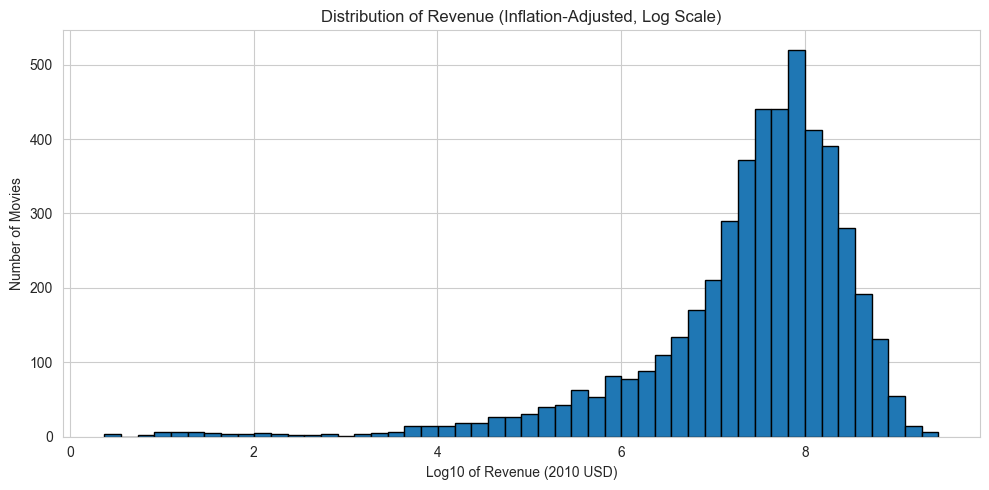

In [16]:
# 1D Exploration: Distribution of revenue (log scale for readability)
fig, ax = plt.subplots(figsize=(10, 5))
df['revenue_adj'].dropna().apply(np.log10).hist(bins=50, ax=ax, edgecolor='black')
ax.set_title('Distribution of Revenue (Inflation-Adjusted, Log Scale)')
ax.set_xlabel('Log10 of Revenue (2010 USD)')
ax.set_ylabel('Number of Movies')
plt.tight_layout()
plt.show()

The revenue distribution is right-skewed even on a log scale, with most movies earning relatively modest amounts and a small number of blockbusters earning over $1 billion.

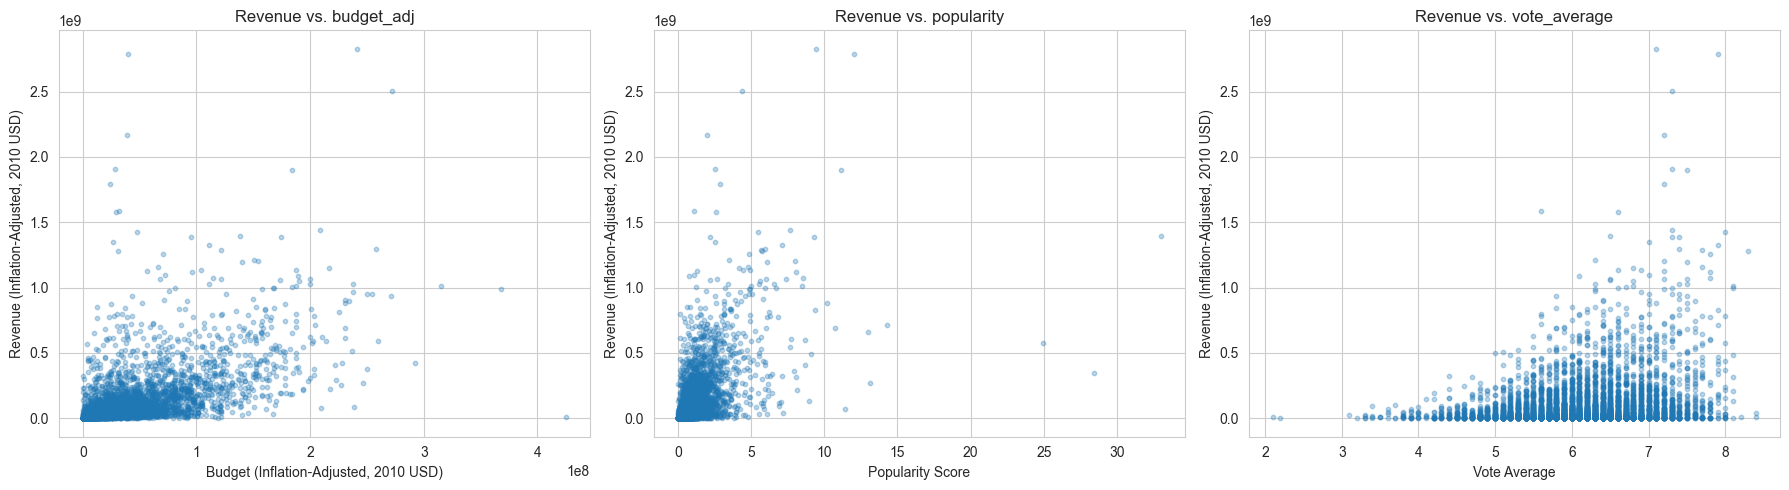

In [17]:
# 2D Exploration: Scatter plots of revenue vs. each independent variable
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

variables = [
    ('budget_adj', 'Budget (Inflation-Adjusted, 2010 USD)'),
    ('popularity', 'Popularity Score'),
    ('vote_average', 'Vote Average'),
]

for ax, (col, label) in zip(axes, variables):
    ax.scatter(df[col], df['revenue_adj'], alpha=0.3, s=10)
    ax.set_xlabel(label)
    ax.set_ylabel('Revenue (Inflation-Adjusted, 2010 USD)')
    ax.set_title(f'Revenue vs. {col}')

plt.tight_layout()
plt.show()

- **Budget vs. Revenue** shows a clear positive relationship — movies with larger budgets tend to generate higher revenue.
- **Popularity vs. Revenue** also shows a positive trend, though with more spread.
- **Vote Average vs. Revenue** has a weaker pattern; highly-rated movies do not necessarily earn the most.

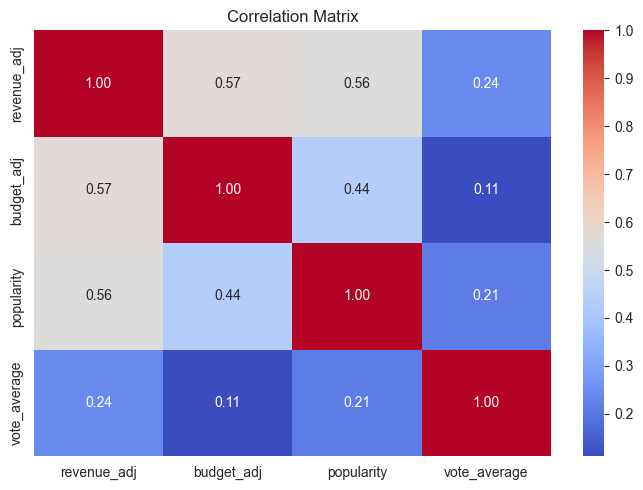

In [18]:
# Correlation matrix for the key numerical variables
cols_of_interest = ['revenue_adj', 'budget_adj', 'popularity', 'vote_average']
corr = df[cols_of_interest].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.show()

The correlation matrix confirms our visual observations:
- `budget_adj` has the strongest positive correlation with `revenue_adj`.
- `popularity` is also positively correlated with revenue.
- `vote_average` shows a weaker correlation with revenue.

This suggests that **budget is the strongest single predictor of revenue** among the variables examined.

### Research Question 2: How has the movie industry changed over the years?

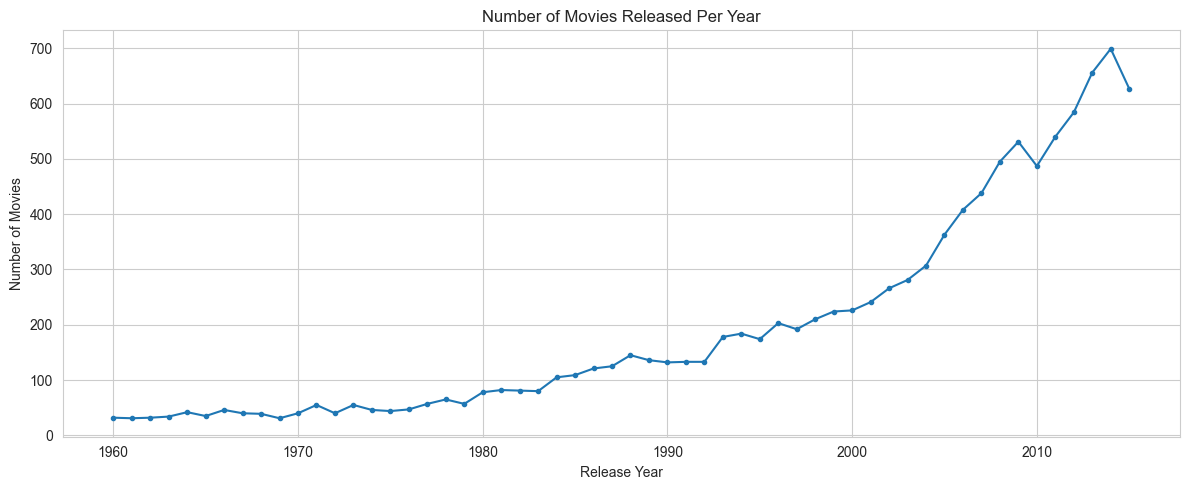

In [19]:
# Number of movies released per year
movies_per_year = df.groupby('release_year').size()

fig, ax = plt.subplots(figsize=(12, 5))
movies_per_year.plot(kind='line', ax=ax, marker='o', markersize=3)
ax.set_title('Number of Movies Released Per Year')
ax.set_xlabel('Release Year')
ax.set_ylabel('Number of Movies')
plt.tight_layout()
plt.show()

The number of movie releases has increased dramatically over time, with a steep rise beginning around the year 2000.

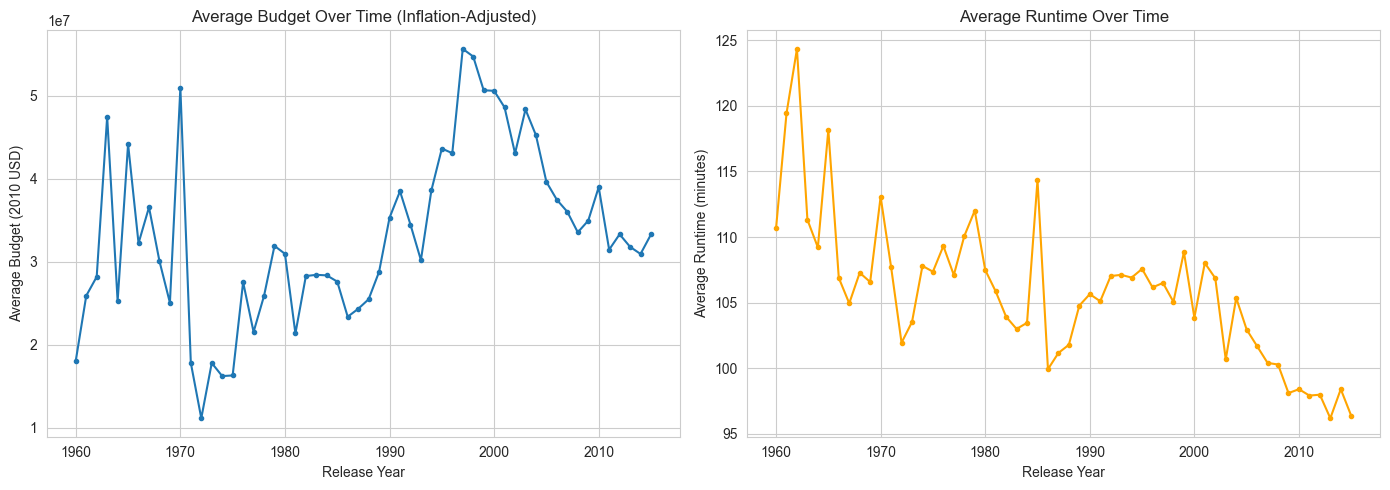

In [20]:
# Average budget and runtime over time
yearly_stats = df.groupby('release_year').agg(
    avg_budget=('budget_adj', 'mean'),
    avg_runtime=('runtime', 'mean')
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(yearly_stats.index, yearly_stats['avg_budget'], marker='o', markersize=3)
axes[0].set_title('Average Budget Over Time (Inflation-Adjusted)')
axes[0].set_xlabel('Release Year')
axes[0].set_ylabel('Average Budget (2010 USD)')

axes[1].plot(yearly_stats.index, yearly_stats['avg_runtime'], marker='o', markersize=3, color='orange')
axes[1].set_title('Average Runtime Over Time')
axes[1].set_xlabel('Release Year')
axes[1].set_ylabel('Average Runtime (minutes)')

plt.tight_layout()
plt.show()

- **Average budget** (inflation-adjusted) has generally decreased over time, which is likely explained by the massive increase in the number of lower-budget films produced in recent decades.
- **Average runtime** was higher in the 1960s–1970s and has stabilized around 100 minutes in recent decades.

### Research Question 3: Which genres are the most profitable and most popular?

In [21]:
def explode_genres(df):
    """Split pipe-separated genres into individual rows."""
    genre_df = df.copy()
    genre_df['genres'] = genre_df['genres'].str.split('|')
    return genre_df.explode('genres')

df_genres = explode_genres(df)
print(f'Unique genres: {df_genres["genres"].nunique()}')
print(df_genres['genres'].value_counts())

Unique genres: 20
genres
Drama              4760
Comedy             3793
Thriller           2907
Action             2384
Romance            1712
Horror             1637
Adventure          1471
Crime              1354
Family             1231
Science Fiction    1229
Fantasy             916
Mystery             810
Animation           699
Documentary         520
Music               408
History             334
War                 270
Foreign             188
TV Movie            167
Western             165
Name: count, dtype: int64


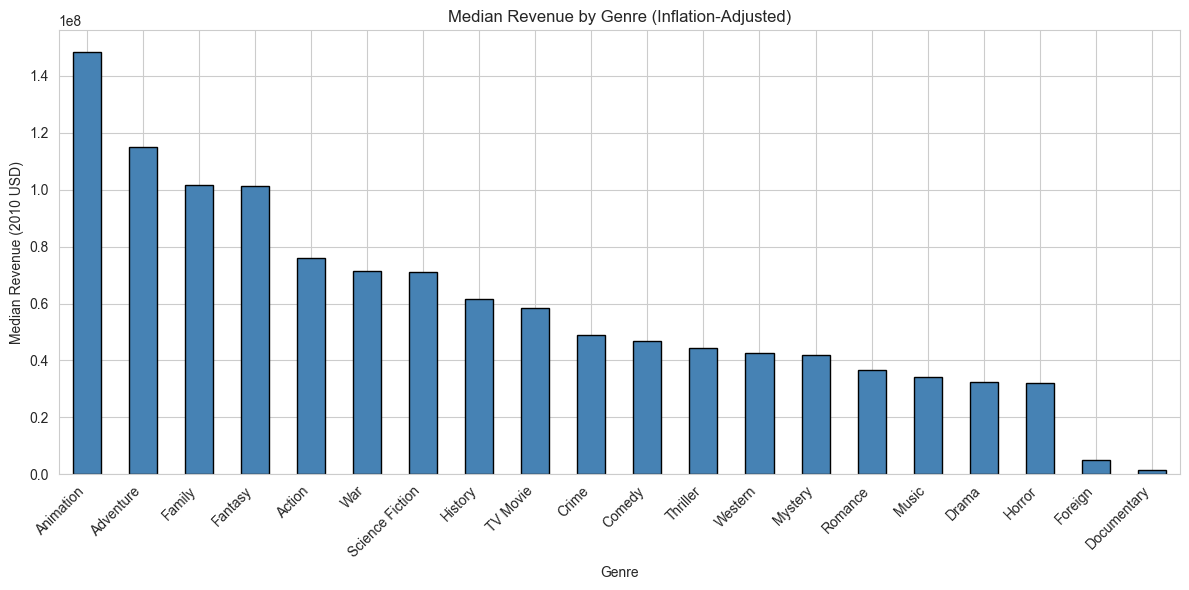

In [22]:
# Median revenue by genre
genre_revenue = df_genres.groupby('genres')['revenue_adj'].median().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
genre_revenue.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Median Revenue by Genre (Inflation-Adjusted)')
ax.set_xlabel('Genre')
ax.set_ylabel('Median Revenue (2010 USD)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Animation**, **Adventure**, and **Fantasy** genres have the highest median revenue. This makes sense as these genres often include big-budget franchise films that attract large audiences.

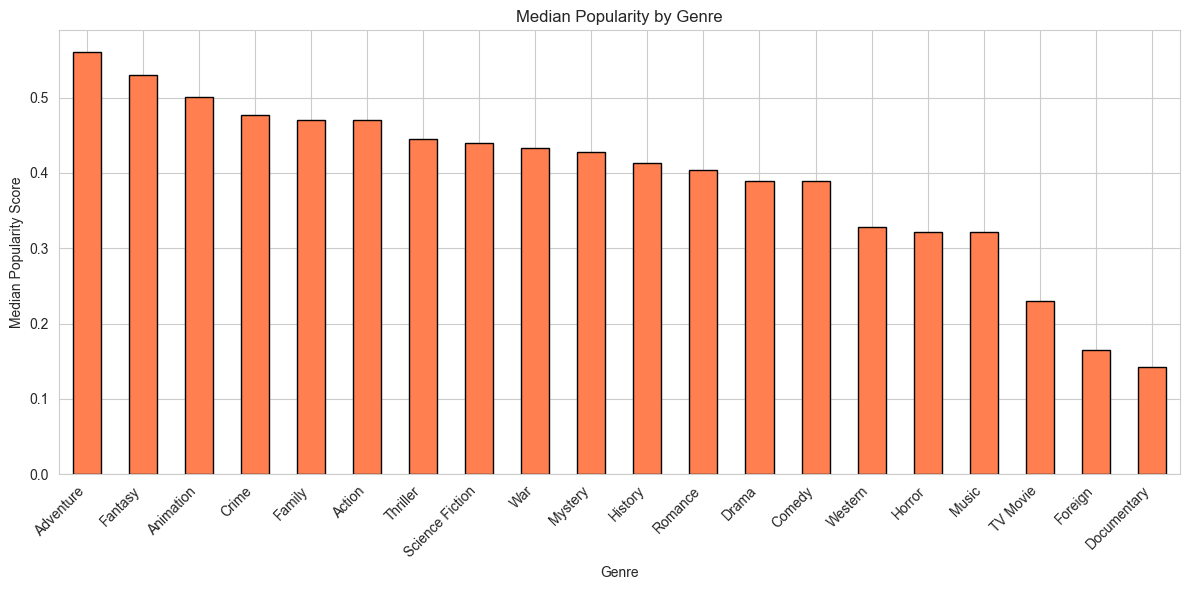

In [23]:
# Median popularity by genre
genre_popularity = df_genres.groupby('genres')['popularity'].median().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
genre_popularity.plot(kind='bar', ax=ax, color='coral', edgecolor='black')
ax.set_title('Median Popularity by Genre')
ax.set_xlabel('Genre')
ax.set_ylabel('Median Popularity Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The popularity rankings largely mirror the revenue rankings, with **Adventure**, **Science Fiction**, and **Fantasy** leading. This supports the idea that genre popularity and box-office revenue are closely related.

<a id='conclusions'></a>
## Conclusions

### Summary of Findings

**Question 1 — What properties are associated with high-revenue movies?**  
Budget is the strongest predictor of revenue among the variables examined (highest positive correlation). Popularity also shows a clear positive relationship with revenue. Vote average, on the other hand, is only weakly correlated — a high rating does not guarantee high earnings.

**Question 2 — How has the movie industry changed over the years?**  
The number of movies released per year has increased dramatically, especially since 2000. The average inflation-adjusted budget has generally declined over time, likely due to a growing number of lower-budget productions. Average runtime peaked in the 1960s–1970s and has since stabilized around 100 minutes.

**Question 3 — Which genres are the most profitable and most popular?**  
Animation, Adventure, and Fantasy lead in median revenue, while Adventure, Science Fiction, and Fantasy rank highest in median popularity. These genres frequently include high-budget franchise films, which explains their strong performance in both metrics.

### Limitations

1. **Correlation, not causation.** The relationships found (e.g., budget → revenue) do not prove that spending more money *causes* higher revenue. Confounding factors (star power, marketing spend, franchise recognition) are not captured in this dataset.
2. **Missing financial data.** A large number of movies had zero values for budget and revenue, which were treated as missing data. This means the financial analyses are biased toward movies for which financial information was available — typically larger, more well-known productions.
3. **Genre overlap.** Most movies belong to multiple genres. Exploding genres into individual rows means a single movie can contribute to several genre groups, so the genre comparisons are not fully independent.
4. **Popularity metric.** The TMDb popularity score is a composite metric whose exact calculation is not fully transparent, making it difficult to interpret precisely.

### Further Research

**Areas for further exploration:**
- **Director and cast influence on revenue.** This dataset includes `director` and `cast` information that was not fully utilized in this analysis. A follow-up study could investigate whether certain directors or actors consistently drive higher revenue, and whether star power has become more or less important over time.
- **Genre trends over time.** While we examined overall genre profitability, it would be valuable to explore how genre popularity has shifted across decades — for example, whether the dominance of superhero and franchise films in recent years has come at the expense of other genres.

**Additional data that would enhance the analysis:**
- **Marketing and advertising budgets.** Production budget alone does not capture the full investment behind a film. Marketing spend data would allow for a more accurate analysis of return on investment and could reveal whether marketing is a stronger predictor of revenue than production budget.
- **Streaming and home media revenue.** This dataset only captures theatrical revenue. With the rise of streaming platforms, a significant portion of a film's total earnings is no longer reflected in box-office numbers. Incorporating streaming viewership data would provide a more complete picture of a film's commercial success.

## Submitting your Project

In [24]:
!python -m nbconvert --to html Investigate_a_Dataset.ipynb

/Users/thomas/Development/Udacity/DataAnalysis/Investigate a Dataset - TMDb_movie_data/proj_venv/bin/python: No module named nbconvert
